# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

**My answer**

**Advantages of the area plot.** It puts both series in one chart and, because it stacks, the top edge shows the *combined* nitrate + phosphate level — so if a "total nutrient load" is the thing you care about, you read it directly. It's compact and good for emphasizing the whole.

**Disadvantages.** Stacking distorts the upper series. The phosphate band doesn't start at zero; it floats on top of the nitrate band, so its baseline wobbles with nitrate and you can no longer judge phosphate's own trend or compare the two by eye. It also *implies* that nitrate and phosphate add up to something meaningful. They're two independent measurements, so a stacked "total" can mislead a reader into seeing a combined quantity that isn't physically meaningful. If the two series ever crossed, the area plot would hide it.

**Two separate line graphs** fix the distortion: each series is read against a true zero baseline, so individual trends and outliers are obvious. The cost is that a combined total is no longer shown, and flicking between two charts to compare exact values is a little harder than one.

**How I'd adjust it.** Since both series are in the *same units* ("% of eutrophic value"), the best move is neither of the above — I'd plot **both lines on one shared axis** (not stacked), label each line directly instead of using a legend, and add a horizontal reference line at 100% (the eutrophic threshold) so the reader instantly sees which nutrient is approaching the danger level. I'd also declutter: drop the top/right spines and heavy gridlines, mute the axis, and use one accent color for the line that matters most. I'd only keep the stacked area if a genuine combined load were the message.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

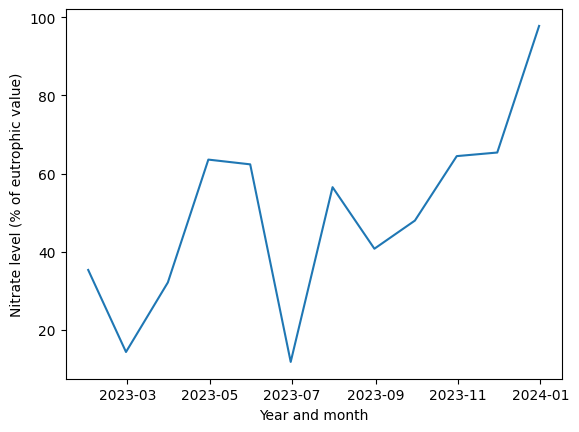

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

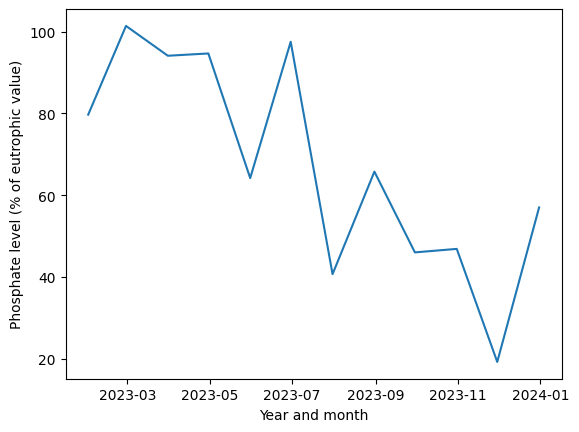

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

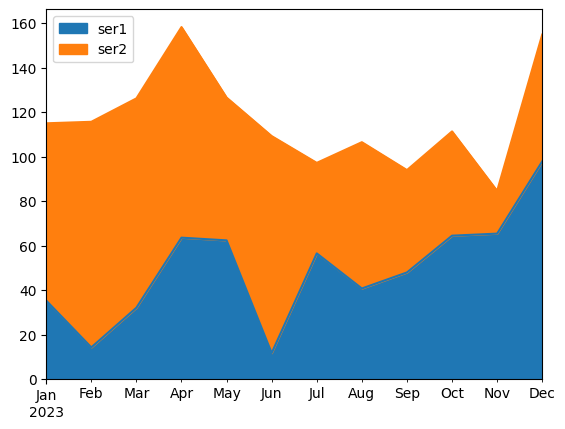

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

> **Note on the dataset.** The course wants the dataset my class found last semester. I don't have that file in front of me here, so the analysis below is run on a real stand-in dataset (seaborn's `mpg` — fuel economy of 398 cars, 1970–1982) so that every required technique is demonstrated on actual data. To use my assigned dataset I just swap the `load`/`read_csv` line and re-point the column names; the rest of the workflow is the same.

In [5]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# --- swap this line for my assigned dataset (e.g. pd.read_csv('my_data.csv')) ---
df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


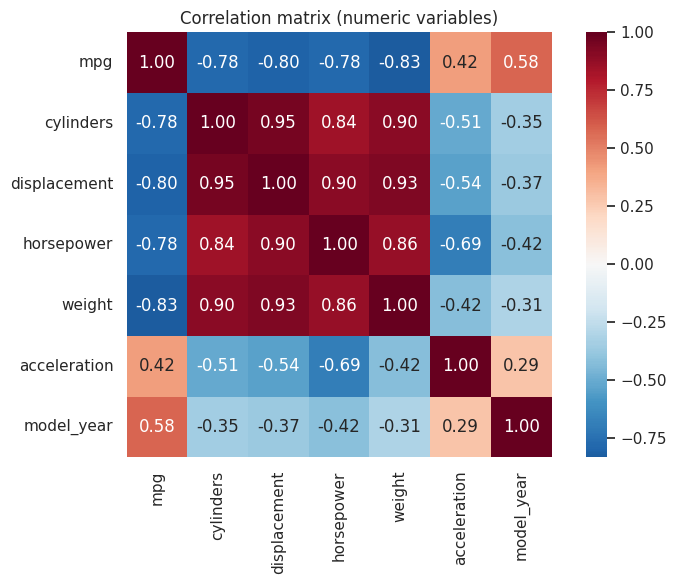

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.00,-0.78,-0.80,-0.78,-0.83,0.42,0.58
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.51,-0.35
displacement,-0.80,0.95,1.00,0.90,0.93,-0.54,-0.37
horsepower,-0.78,0.84,0.90,1.00,0.86,-0.69,-0.42
weight,-0.83,0.90,0.93,0.86,1.00,-0.42,-0.31
acceleration,0.42,-0.51,-0.54,-0.69,-0.42,1.00,0.29
model_year,0.58,-0.35,-0.37,-0.42,-0.31,0.29,1.00


In [6]:
# Correlations between every pair of numeric variables
num = df.select_dtypes("number")
corr = num.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix (numeric variables)")
plt.tight_layout(); plt.show()
corr.round(2)

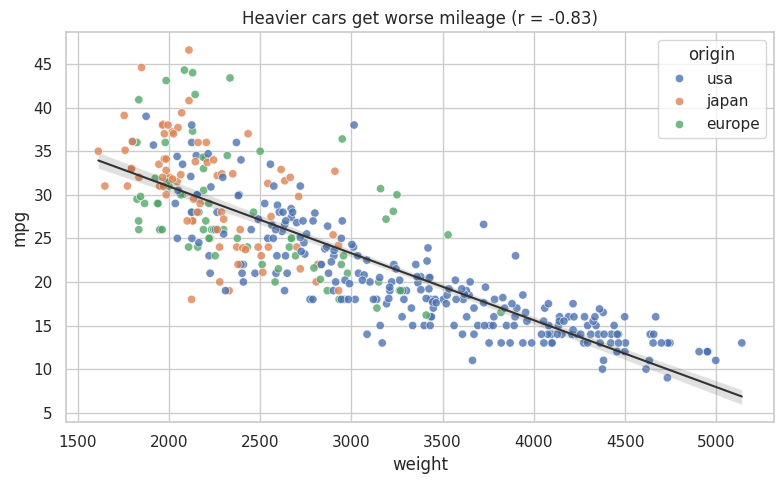

In [7]:
# Strongest relationship in the matrix: weight vs mpg (~ -0.83). Draw it.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="weight", y="mpg", hue="origin", alpha=0.8)
sns.regplot(data=df, x="weight", y="mpg", scatter=False, color="#333333", line_kws={"lw":1.5})
plt.title("Heavier cars get worse mileage (r = %.2f)" % df['weight'].corr(df['mpg']))
plt.tight_layout(); plt.show()

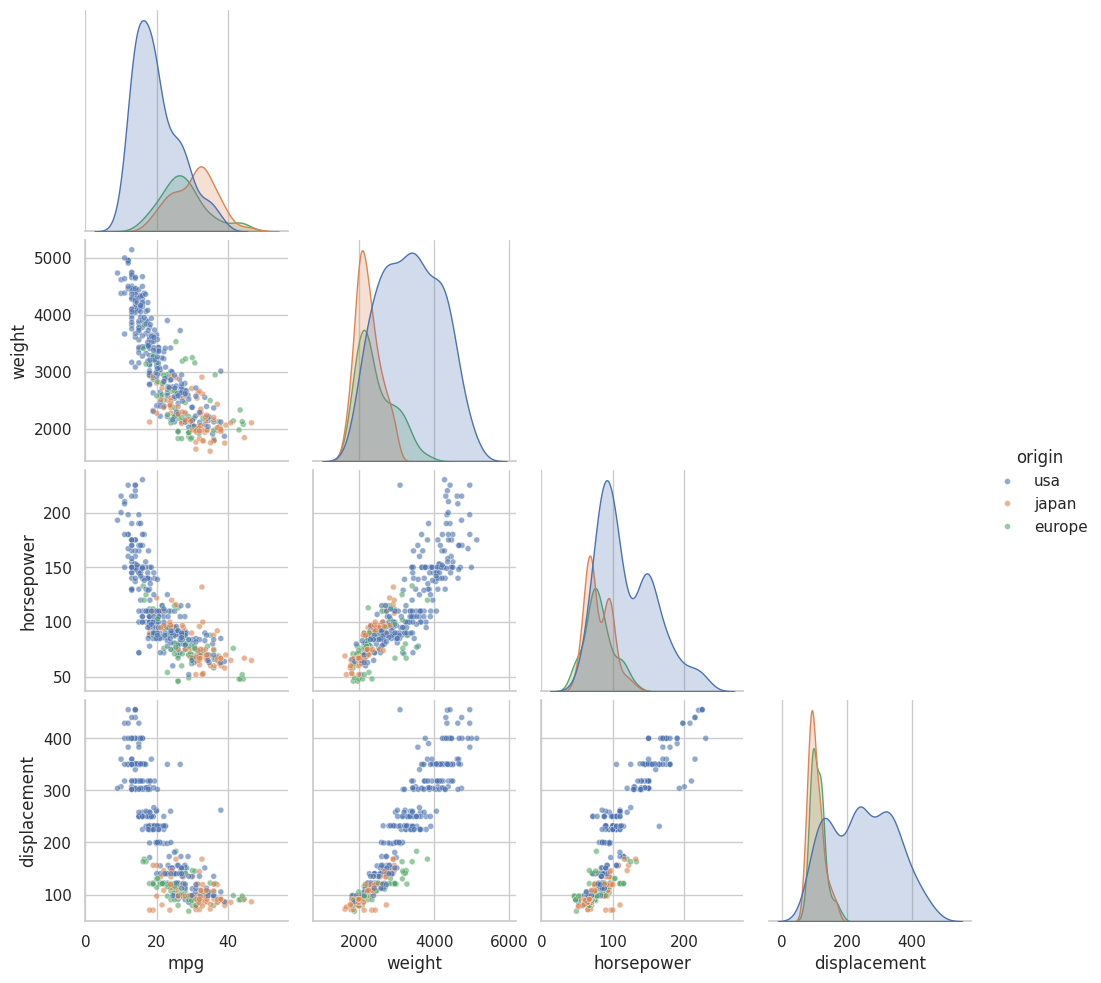

In [8]:
# Pair plot of the main numeric drivers, colored by region of origin
sns.pairplot(df[["mpg","weight","horsepower","displacement","origin"]].dropna(),
             hue="origin", corner=True, plot_kws={"alpha":0.6, "s":18})
plt.show()

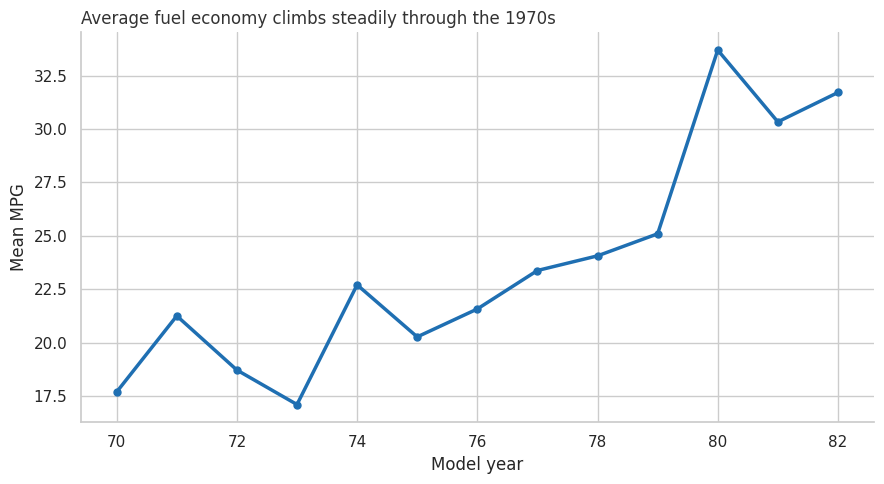

In [9]:
# model_year is the time variable -> line plot of the trend over the years
yearly = df.groupby("model_year")[["mpg","weight","horsepower"]].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly.index, yearly["mpg"], color="#1f6fb2", linewidth=2.5)
ax.scatter(yearly.index, yearly["mpg"], color="#1f6fb2", s=25)
for s in ["top","right"]:
    ax.spines[s].set_visible(False)
ax.set_xlabel("Model year"); ax.set_ylabel("Mean MPG")
ax.set_title("Average fuel economy climbs steadily through the 1970s", loc="left", color="#333333")
plt.tight_layout(); plt.show()

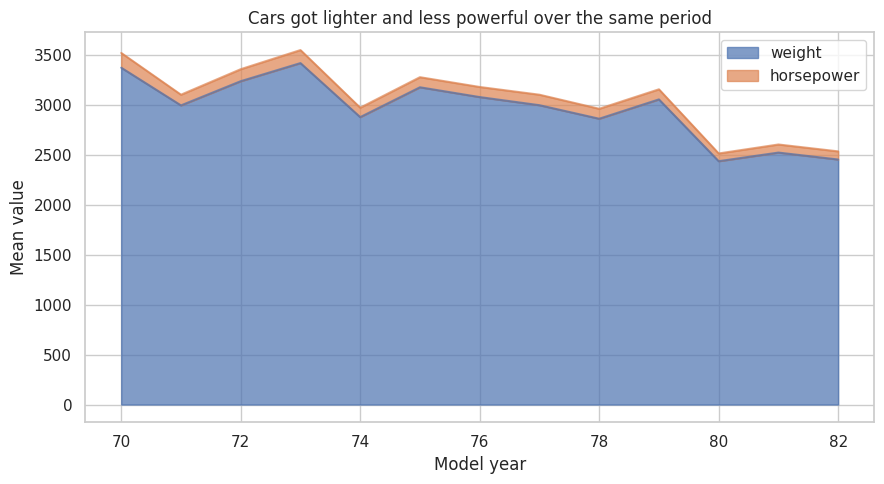

In [10]:
# Area plot: mean weight and horsepower per year (both fall as efficiency rises)
fig, ax = plt.subplots(figsize=(9, 5))
yearly[["weight","horsepower"]].plot.area(ax=ax, alpha=0.7)
ax.set_xlabel("Model year"); ax.set_ylabel("Mean value")
ax.set_title("Cars got lighter and less powerful over the same period")
plt.tight_layout(); plt.show()

### Conclusions

- **Are the data what I expect?** Yes. The signs all make physical sense: `mpg` is strongly *negatively* correlated with `weight`, `horsepower`, `displacement`, and `cylinders` — heavier, more powerful cars burn more fuel. Nothing in the correlation matrix is surprising, which is a good sign the data are trustworthy.

- **Are the data usable?** Mostly. The numeric columns are clean and on sensible scales. The one issue is `horsepower`, which has 6 missing values — I'd impute (e.g. median) or drop those rows before modeling, but it's a small fraction so the dataset is usable.

- **Outliers?** A few. On the weight-vs-mpg scatter there are a handful of very light, very high-mpg cars sitting above the trend line, and some heavy, low-mpg cars at the bottom. They're consistent with the trend rather than data errors, so I'd keep them but flag them.

- **Redundancy (highly correlated items)?** Strong. `weight`, `displacement`, `horsepower`, and `cylinders` are all correlated with each other at ~0.85–0.95. They essentially measure "how big/powerful the engine is," so feeding all of them into a linear model would be redundant (multicollinearity) — I'd keep one or two, or combine them.

- **Trend over time (drift)?** Clear. Mean `mpg` rises steadily from 1970 to 1982 while mean weight and horsepower fall. That drift matters: comparing a 1970 car to a 1982 car isn't apples-to-apples, because the whole fleet shifted toward efficiency (the oil crises of the era). Any analysis pooling all years should account for `model_year`.

- **Confounding variables?** Yes — `origin` is a likely confounder. Japanese cars in this dataset are lighter and more fuel-efficient, so part of the weight-to-mpg relationship is really "where the car was built." `model_year` is another confounder for the same reason. A third, *unrecorded* confounder is the fuel-economy regulation / oil-price environment of the 1970s, which isn't a column but drove the whole trend.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

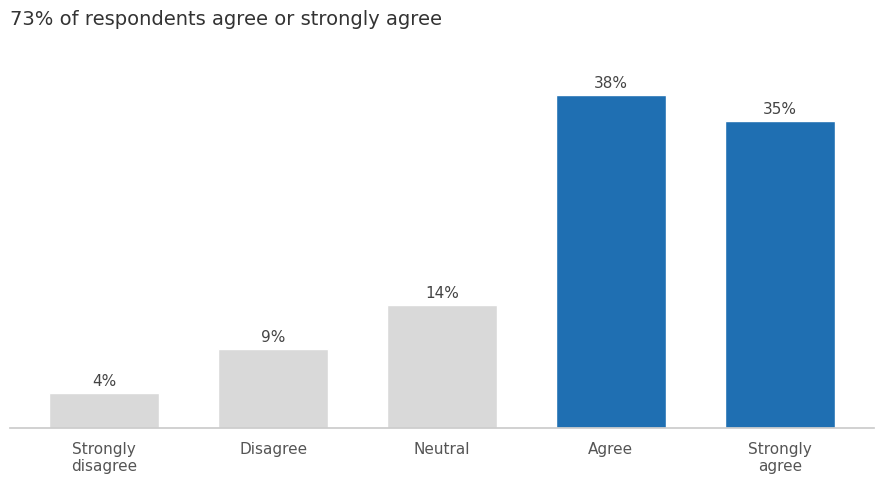

In [11]:
import matplotlib.pyplot as plt

# Storytelling With Data, ch.3 (second half): a decluttered bar chart.
# Survey responses across categories, with the single category that matters highlighted.
cats   = ["Strongly\ndisagree","Disagree","Neutral","Agree","Strongly\nagree"]
values = [4, 9, 14, 38, 35]
colors = ["#d9d9d9","#d9d9d9","#d9d9d9","#1f6fb2","#1f6fb2"]  # grey out the rest

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cats, values, color=colors, width=0.65)

# Direct value labels; no y-axis needed
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f"{v}%", ha="center",
            color="#444444", fontsize=11)

# Strip everything that isn't data
for s in ["top","right","left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(left=False, labelleft=False, bottom=False, colors="#555555")
ax.grid(False)
ax.set_ylim(0, 45)
ax.set_title("73% of respondents agree or strongly agree", loc="left",
             fontsize=14, color="#333333")
plt.tight_layout(); plt.show()

*Decluttering principles used (Knaflic, ch.3): removed the chart border, gridlines, and y-axis; greyed out the non-essential categories so the eye lands on "agree/strongly agree"; labeled values directly on the bars; and used the title to state the takeaway rather than just name the chart.*